In [52]:
import os
import pandas as pd
import numpy as np
from statsbombpy import sb
import warnings
from mplsoccer import Pitch
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

In [53]:
wc_2022 = sb.matches(competition_id=43, season_id=106)
wc_2018 = sb.matches(competition_id=43, season_id=3)
euro_2024 = sb.matches(competition_id=55, season_id=282)

print(f"WC 2022: {len(wc_2022)} matches")
print(f"WC 2018: {len(wc_2018)} matches")
print(f"Euro 2024: {len(euro_2024)} matches")

WC 2022: 64 matches
WC 2018: 64 matches
Euro 2024: 51 matches


In [54]:
os.makedirs('data', exist_ok=True)

all_matches = pd.concat([wc_2022, wc_2018, euro_2024])
match_ids = all_matches['match_id'].tolist()

events_list = []
for i, match_id in enumerate(match_ids):
    try:
        events = sb.events(match_id=match_id)
        events['match_id'] = match_id
        events_list.append(events)
        if i % 20 == 0:
            print(f"Pulled {i}/{len(match_ids)} matches")
    except Exception as e:
        print(f"Failed match {match_id}: {e}")

all_events = pd.concat(events_list, ignore_index=True)
all_events.to_csv('data/all_events.csv', index=False)
print(f"Total events: {len(all_events):,}")


Pulled 0/179 matches
Pulled 20/179 matches
Pulled 40/179 matches
Pulled 60/179 matches
Pulled 80/179 matches
Pulled 100/179 matches
Pulled 120/179 matches
Pulled 140/179 matches
Pulled 160/179 matches
Total events: 650,386


In [55]:
shots = all_events[all_events['type'] == 'Shot'].copy()
shots.to_csv('data/shots.csv', index=False)
print(f"Total shots: {len(shots):,}")
print(f"Total goals: {(shots['shot_outcome'] == 'Goal').sum()}")
print(f"Conversion rate: {(shots['shot_outcome'] == 'Goal').mean():.1%}")

Total shots: 4,540
Total goals: 504
Conversion rate: 11.1%


In [56]:
shots['x'] = shots['location'].apply(lambda loc: loc[0] if isinstance(loc, list) else None)
shots['y'] = shots['location'].apply(lambda loc: loc[1] if isinstance(loc, list) else None)
shots = shots.dropna(subset=['x', 'y'])

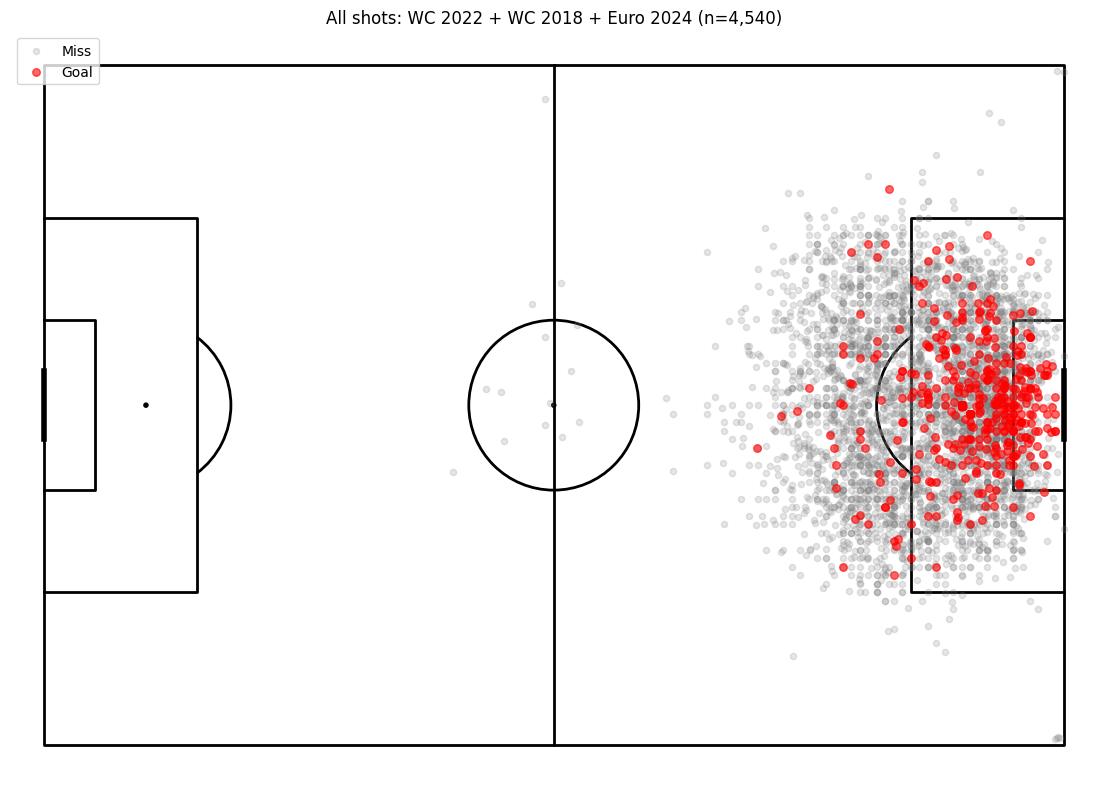

In [57]:
pitch = Pitch(pitch_type='statsbomb', line_color='black')
fig, ax = pitch.draw(figsize=(12, 8))

# Plot all shots, goals in red, misses in grey
goals = shots[shots['shot_outcome'] == 'Goal']
misses = shots[shots['shot_outcome'] != 'Goal']

pitch.scatter(misses['x'], misses['y'], alpha=0.2, s=20, color='grey', ax=ax, label='Miss')
pitch.scatter(goals['x'], goals['y'], alpha=0.6, s=30, color='red', ax=ax, label='Goal')
ax.legend()
plt.title(f'All shots: WC 2022 + WC 2018 + Euro 2024 (n={len(shots):,})')
plt.savefig('outputs/01_shot_map.png', dpi=150, bbox_inches='tight')
plt.show()

In [58]:
shots["distance"] = np.sqrt((120 - shots['x'])**2 + (40 - shots['y'])**2)
shots['distance_bin'] = pd.cut(shots['distance'], bins=[0, 5, 10, 15, 20, 25, 30, 50])
conversion_by_distance = shots.groupby('distance_bin', observed=True).apply(
    lambda g: (g['shot_outcome'] == 'Goal').mean()
)

print(conversion_by_distance)

distance_bin
(0, 5]      0.450704
(5, 10]     0.198830
(10, 15]    0.200962
(15, 20]    0.081146
(20, 25]    0.037927
(25, 30]    0.033333
(30, 50]    0.015837
dtype: float64


In [59]:
shots['body_part'] = shots['shot_body_part']
body_part_stats = shots.groupby("body_part").agg(
    shots=("id", "count"),
    goals=("shot_outcome", lambda x: (x == 'Goal').sum()),
)

body_part_stats['conversion'] = body_part_stats['goals'] / body_part_stats["shots"]
print(body_part_stats)

            shots  goals  conversion
body_part                           
Head          790     78    0.098734
Left Foot    1353    145    0.107169
Other          34      5    0.147059
Right Foot   2363    276    0.116801


In [60]:
def shot_angle(x,y,goal_width=7.32, pitch_length=120):
    dx = pitch_length - x
    dy1 = 36 - y
    dy2 = 44 - y
    angle = np.arctan2(dy2, dx) - np.arctan2(dy1, dx)
    return np.abs(np.degrees(angle))

shots["angle"] = shots.apply(lambda r: shot_angle(r['x'], r['y']), axis=1)

In [61]:
wc_2022_match_ids = wc_2022['match_id'].tolist()

frames_list = []
for i, match_id in enumerate(wc_2022_match_ids):
    try:
        frames = sb.frames(match_id=match_id)
        frames_list.append(frames)
        if i % 10 == 0:
            print(f"Pulled {i}/{len(wc_2022_match_ids)} matches")
    except Exception as e:
        print(f"Failed match {match_id}: {e}")
all_frames = pd.concat(frames_list, ignore_index=True)
all_frames.to_csv('data/all_frames.csv', index=False)

Pulled 0/64 matches
Pulled 10/64 matches
Pulled 20/64 matches
Pulled 30/64 matches
Pulled 40/64 matches
Pulled 50/64 matches
Pulled 60/64 matches


In [62]:
shots = pd.read_csv('data/shots.csv')

# Filter to shots that have freeze_frame data (WC 2022 only — earlier tournaments don't)
shots_with_ff = shots[shots['shot_freeze_frame'].notna()].copy()
print(f"Shots with freeze-frame data: {len(shots_with_ff)}")
print(f"Total shots: {len(shots)}")

Shots with freeze-frame data: 4381
Total shots: 4540


In [63]:
# def defenders_in_cone(shot_x, shot_y, frame_df):
#     opponents = frame_df[(frame_df["teammate"] == False) & (frame_df["actor"] == False)]
#     if len(opponents ) == 0:
#         return 0
    
#     count = 0
#     for _, opp in opponents.iterrows():
#         opp_x, opp_y = opp["location"][0], opp["location"][1]
#         if opp_x <= shot_x:
#             continue

#         t = (opp_x - shot_x) / (120 - shot_x) if (120 - shot_x) > 0 else 0
#         upper_y = shot_y + t * (40 - shot_y)
#         lower_y = shot_y + t * (36 - shot_y)
#         y_min, y_max = min(upper_y, lower_y), max(upper_y, lower_y)
#         if y_min <= opp_y <= y_max:
#             count += 1
#     return count


# shots_2022 = shots[shots['match_id'].isin(wc_2022_match_ids)].copy()
# defender_counts = []
# for _, shot in shots_2022.iterrows():
#     frame= all_frames[(all_frames['id'] == shot['id'])]
#     defender_counts.append(defenders_in_cone(shot['x'], shot['y'], frame))
# shots_2022['defenders_in_cone'] = defender_counts

In [64]:
import ast

def parse_freeze_frame(ff):
    if isinstance(ff, list):
        return ff  # already parsed
    if isinstance(ff, str):
        try:
            return ast.literal_eval(ff)
        except (ValueError, SyntaxError):
            return None
    return None

shots_with_ff['shot_freeze_frame'] = shots_with_ff['shot_freeze_frame'].apply(parse_freeze_frame)

# Verify the fix
sample = shots_with_ff['shot_freeze_frame'].iloc[0]
print(f"Type after parsing: {type(sample)}")
print(f"Number of players in first freeze frame: {len(sample)}")
print(f"\nFirst player entry:")
print(sample[0])

# How many parsed successfully?
parsed_count = shots_with_ff['shot_freeze_frame'].apply(lambda x: isinstance(x, list)).sum()
print(f"\nParsed successfully: {parsed_count} of {len(shots_with_ff)}")

Type after parsing: <class 'list'>
Number of players in first freeze frame: 19

First player entry:
{'location': [108.6, 34.8], 'player': {'id': 9922, 'name': 'David Junior Hoilett'}, 'position': {'id': 19, 'name': 'Center Attacking Midfield'}, 'teammate': True}

Parsed successfully: 4381 of 4381


In [65]:
import ast

def defenders_in_cone(shot_location, freeze_frame):
    if not isinstance(freeze_frame, list) or len(freeze_frame) == 0:
        return None
    
    shot_x, shot_y = shot_location[0], shot_location[1]
    count = 0
    
    for player in freeze_frame:
        if player.get('teammate', True):
            continue
        
        loc = player.get('location')
        if not loc:
            continue
        opp_x, opp_y = loc[0], loc[1]
        
        if opp_x <= shot_x:
            continue
        
        if (120 - shot_x) > 0:
            t = (opp_x - shot_x) / (120 - shot_x)
        else:
            t = 0
        
        upper_y = shot_y + t * (44 - shot_y)
        lower_y = shot_y + t * (36 - shot_y)
        y_min = min(upper_y, lower_y)
        y_max = max(upper_y, lower_y)
        
        if y_min <= opp_y <= y_max:
            count += 1
    
    return count

def _as_literal(value):
    if isinstance(value, str):
        try:
            return ast.literal_eval(value)
        except (ValueError, SyntaxError):
            return value
    return value

shots_with_ff['defenders_in_cone'] = shots_with_ff.apply(
    lambda row: defenders_in_cone(
        _as_literal(row['location']),
        _as_literal(row['shot_freeze_frame'])
    ),
    axis=1
)

print(f"Mean defenders in cone: {shots_with_ff['defenders_in_cone'].mean():.2f}")
print(f"Distribution of defender counts:")
print(shots_with_ff['defenders_in_cone'].value_counts().sort_index())
print(f"\nConversion rate by defender count:")
print(shots_with_ff.groupby('defenders_in_cone').apply(
    lambda g: pd.Series({
        'shots': len(g),
        'goals': (g['shot_outcome'] == 'Goal').sum(),
        'conversion_rate': (g['shot_outcome'] == 'Goal').mean()
    })
).round(3))

Mean defenders in cone: 1.77
Distribution of defender counts:
defenders_in_cone
0     110
1    1979
2    1486
3     526
4     198
5      60
6      19
7       3
Name: count, dtype: int64

Conversion rate by defender count:
                    shots  goals  conversion_rate
defenders_in_cone                                
0                   110.0   31.0            0.282
1                  1979.0  234.0            0.118
2                  1486.0   86.0            0.058
3                   526.0   25.0            0.048
4                   198.0    6.0            0.030
5                    60.0    1.0            0.017
6                    19.0    1.0            0.053
7                     3.0    1.0            0.333


In [66]:
sample_ff = shots_with_ff['shot_freeze_frame'].iloc[0]
print(f"Type of freeze_frame: {type(sample_ff)}")
print(f"Length: {len(sample_ff) if hasattr(sample_ff, '__len__') else 'N/A'}")
print(f"\nFirst element:")
print(sample_ff[0] if hasattr(sample_ff, '__getitem__') else sample_ff)

Type of freeze_frame: <class 'list'>
Length: 19

First element:
{'location': [108.6, 34.8], 'player': {'id': 9922, 'name': 'David Junior Hoilett'}, 'position': {'id': 19, 'name': 'Center Attacking Midfield'}, 'teammate': True}


In [67]:
# Check 2: Are freeze frames stored as lists, or something else like strings/dicts?
print(f"\nShape and dtype check:")
print(shots_with_ff['shot_freeze_frame'].dtype)
print(f"\nIs every freeze frame a list? {shots_with_ff['shot_freeze_frame'].apply(lambda x: isinstance(x, list)).sum()} of {len(shots_with_ff)}")
print(f"Is every freeze frame a numpy array? {shots_with_ff['shot_freeze_frame'].apply(lambda x: hasattr(x, '__array__')).sum()} of {len(shots_with_ff)}")


Shape and dtype check:
object

Is every freeze frame a list? 4381 of 4381
Is every freeze frame a numpy array? 0 of 4381


In [68]:
# Check 3: Just dump one full freeze frame so we can see everything
import json
print(json.dumps(sample_ff, indent=2, default=str)[:2000])

[
  {
    "location": [
      108.6,
      34.8
    ],
    "player": {
      "id": 9922,
      "name": "David Junior Hoilett"
    },
    "position": {
      "id": 19,
      "name": "Center Attacking Midfield"
    },
    "teammate": true
  },
  {
    "location": [
      112.7,
      45.5
    ],
    "player": {
      "id": 16459,
      "name": "Cyle Larin"
    },
    "position": {
      "id": 23,
      "name": "Center Forward"
    },
    "teammate": true
  },
  {
    "location": [
      108.6,
      42.5
    ],
    "player": {
      "id": 12770,
      "name": "Jonathan Osorio"
    },
    "position": {
      "id": 9,
      "name": "Right Defensive Midfield"
    },
    "teammate": true
  },
  {
    "location": [
      109.2,
      27.6
    ],
    "player": {
      "id": 24024,
      "name": "Tajon Buchanan"
    },
    "position": {
      "id": 16,
      "name": "Left Midfield"
    },
    "teammate": true
  },
  {
    "location": [
      94.4,
      20.6
    ],
    "player": {
      "id": 2

In [69]:
print(shots_2022.groupby('defenders_in_cone').apply(
    lambda g: (g['shot_outcome'] == 'Goal').mean()
))

defenders_in_cone
0    0.153627
1    0.129296
2    0.054054
3    0.000000
4    0.000000
5    0.000000
dtype: float64


In [75]:
# def build_features(shots_df):
#     features = pd.DataFrame()
#     features['distance'] = shots_df['distance']
#     features['angle'] = shots_df['angle']
#     features['x'] = shots_df['x']
#     features['y_centered'] = (shots_df['y'] - 40).abs()  # distance from center line
    
#     # Body part
#     features['is_header'] = (shots_df['shot_body_part'] == 'Head').astype(int)
#     features['is_right_foot'] = (shots_df['shot_body_part'] == 'Right Foot').astype(int)
#     features['is_left_foot'] = (shots_df['shot_body_part'] == 'Left Foot').astype(int)
    
#     # Pattern of play
#     features['is_open_play'] = (shots_df['play_pattern'] == 'Regular Play').astype(int)
#     features['is_corner'] = (shots_df['play_pattern'] == 'From Corner').astype(int)
#     features['is_free_kick'] = (shots_df['play_pattern'] == 'From Free Kick').astype(int)
#     features['is_counter'] = (shots_df['play_pattern'] == 'From Counter').astype(int)
    
#     # Shot technique
#     features['is_volley'] = (shots_df['shot_technique'] == 'Volley').astype(int)
#     features['is_first_time'] = shots_df['shot_first_time'].fillna(False).astype(int)
    
#     # Target
#     features['is_goal'] = (shots_df['shot_outcome'] == 'Goal').astype(int)
    
#     return features
# features = build_features(shots)
# # features.to_csv('data/features.csv', index=False)

In [76]:
def build_features(shots_df, include_defenders=False):
    features = pd.DataFrame()
    features['distance'] = shots_df['distance']
    features['angle'] = shots_df['angle']
    features['x'] = shots_df['x']
    features['y_centered'] = (shots_df['y'] - 40).abs()  # distance from center line
    
    # Body part
    features['is_header'] = (shots_df['shot_body_part'] == 'Head').astype(int)
    features['is_right_foot'] = (shots_df['shot_body_part'] == 'Right Foot').astype(int)
    features['is_left_foot'] = (shots_df['shot_body_part'] == 'Left Foot').astype(int)
    
    # Pattern of play 
    features['is_open_play'] = (shots_df['play_pattern'] == 'Regular Play').astype(int)
    features['is_corner'] = (shots_df['play_pattern'] == 'From Corner').astype(int)
    features['is_free_kick'] = (shots_df['play_pattern'] == 'From Free Kick').astype(int)
    features['is_counter'] = (shots_df['play_pattern'] == 'From Counter').astype(int)
    
    # Shot technique
    features['is_volley'] = (shots_df['shot_technique'] == 'Volley').astype(int)
    features['is_one_on_one'] = shots_df['shot_one_on_one'].fillna(False).astype(int)
    features['is_open_goal'] = shots_df['shot_open_goal'].fillna(False).astype(int)
    features['under_pressure'] = shots_df['under_pressure'].fillna(False).astype(int)
    features['is_first_time'] = shots_df['shot_first_time'].fillna(False).astype(int)

    # The new feature for defenders in cone
    if include_defenders:
        features['defenders_in_cone'] = shots_df['defenders_in_cone'].fillna(0)
    
    # Target
    features['is_goal'] = (shots_df['shot_outcome'] == 'Goal').astype(int)
    
    return features

def _parse_location(value):
    if isinstance(value, str):
        try:
            value = ast.literal_eval(value)
        except (ValueError, SyntaxError):
            return None
    return value if isinstance(value, (list, tuple)) else None

shots = pd.read_csv('data/shots.csv')
shots['location'] = shots['location'].apply(_parse_location)

shots['x'] = shots['location'].apply(lambda loc: loc[0] if isinstance(loc, (list, tuple)) else np.nan)
shots['y'] = shots['location'].apply(lambda loc: loc[1] if isinstance(loc, (list, tuple)) else np.nan)
shots = shots.dropna(subset=['x', 'y'])

if 'distance' not in shots.columns:
    shots['distance'] = np.sqrt((120 - shots['x'])**2 + (40 - shots['y'])**2)

def shot_angle(x, y, goal_width=7.32, pitch_length=120):
    dx = pitch_length - x
    dy1 = 36 - y
    dy2 = 44 - y
    angle = np.arctan2(dy2, dx) - np.arctan2(dy1, dx)
    return np.abs(np.degrees(angle))

if 'angle' not in shots.columns:
    shots['angle'] = shots.apply(lambda r: shot_angle(r['x'], r['y']), axis=1)

features = build_features(shots, include_defenders=False)
# Merge the freeze-frame defender counts back onto the main shot dataset
shots_with_defenders = shots.merge(
    shots_with_ff[['id', 'defenders_in_cone']].drop_duplicates('id'),
    on='id',
    how='left'
)

# Fill missing defender counts with 0 (shots without freeze-frame data)
shots_with_defenders['defenders_in_cone'] = shots_with_defenders['defenders_in_cone'].fillna(0)

features_with_defenders = build_features(shots_with_defenders, include_defenders=True)
features.to_csv('data/features.csv', index=False)
features_with_defenders.to_csv('data/features_with_defenders.csv', index=False)


print(f"Without 360: {features.shape[1] - 1} features")
print(f"With 360:    {features_with_defenders.shape[1] - 1} features")

Without 360: 16 features
With 360:    17 features
